MC scale:      3.2896e-02
Offbeam scale: 9.5295e-02
Rock scale:    1.3835e+00  (rock POT = 1.7067e+19)
Loading MC preselection tree...
Computing PPFX weights (nominal)...
Computing PPFX weights (rock)...
Nominal: νμ 593565, ν̄μ 111218, mean weight 0.9984
Rock:    νμ 1284, ν̄μ 286, mean weight 1.0000


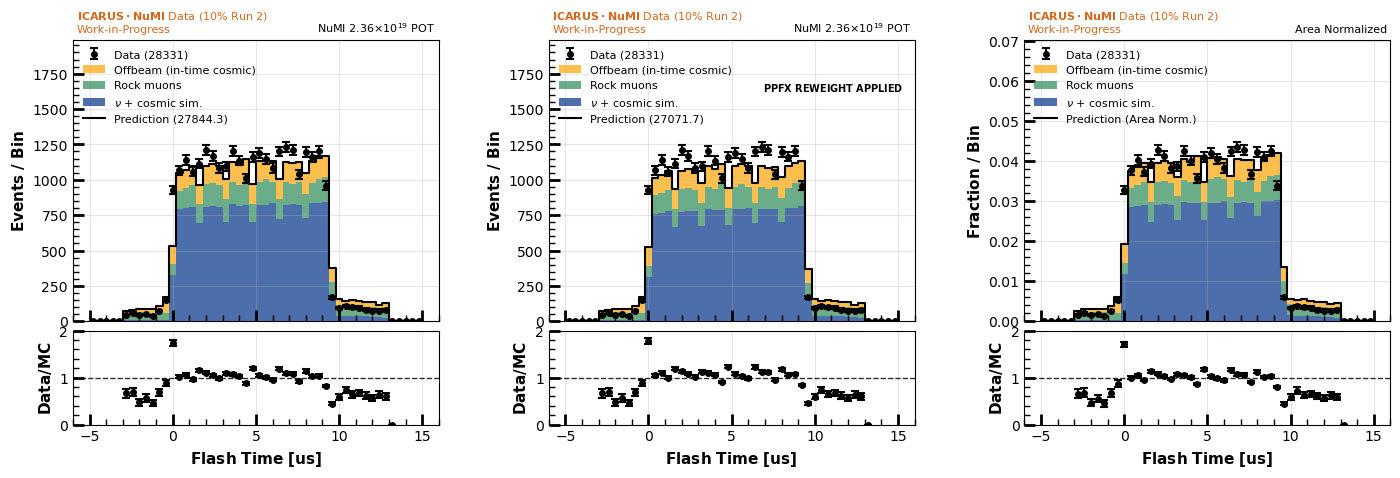

Saved: preselection_flash_time


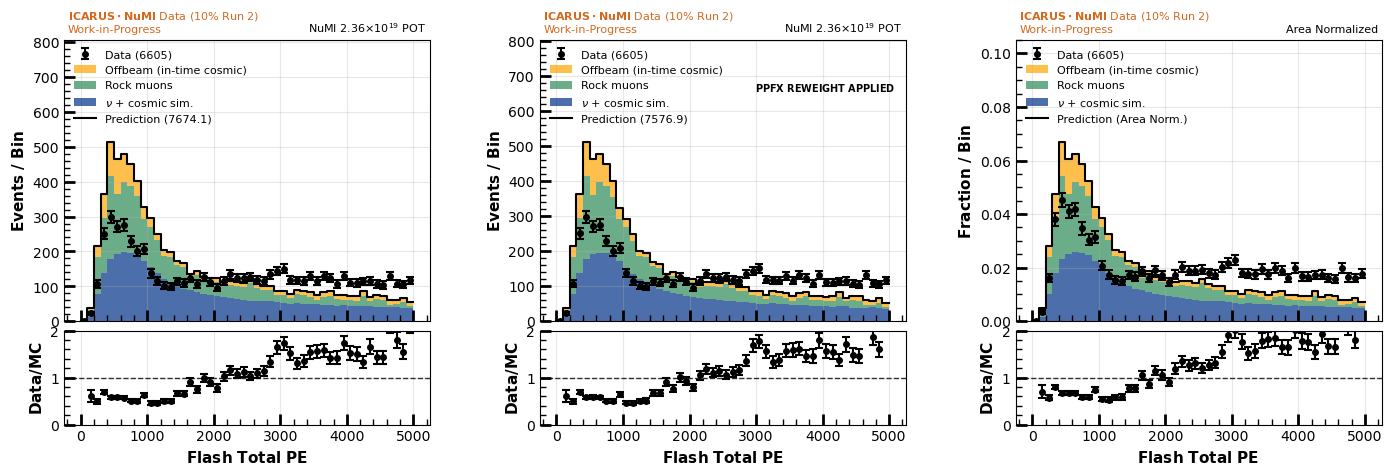

Saved: preselection_flash_total_pe


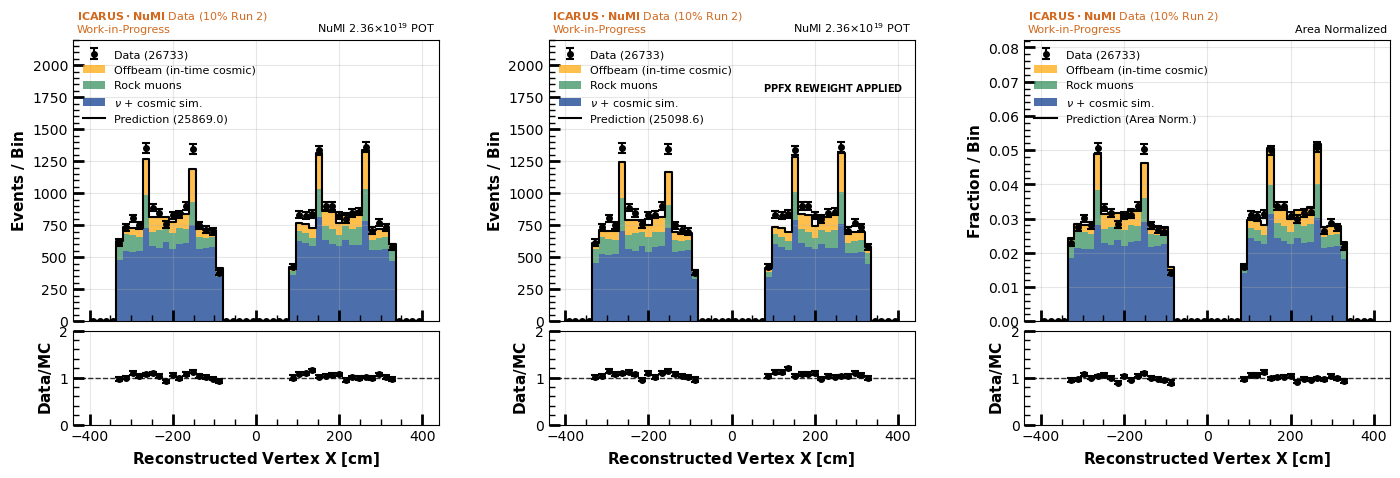

Saved: preselection_vertex_x


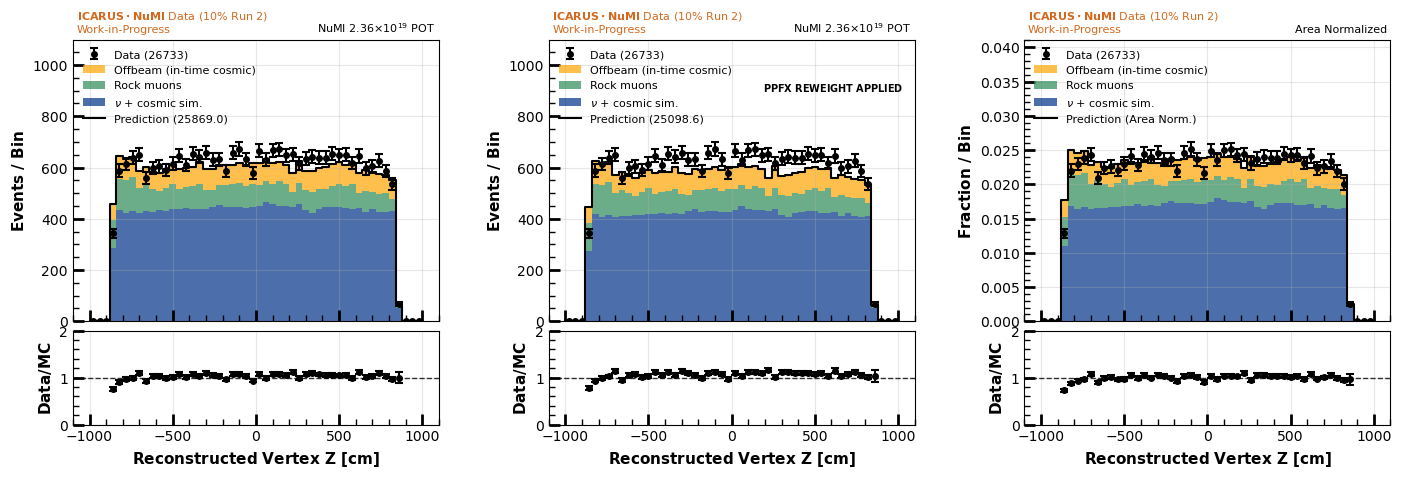

Saved: preselection_vertex_z


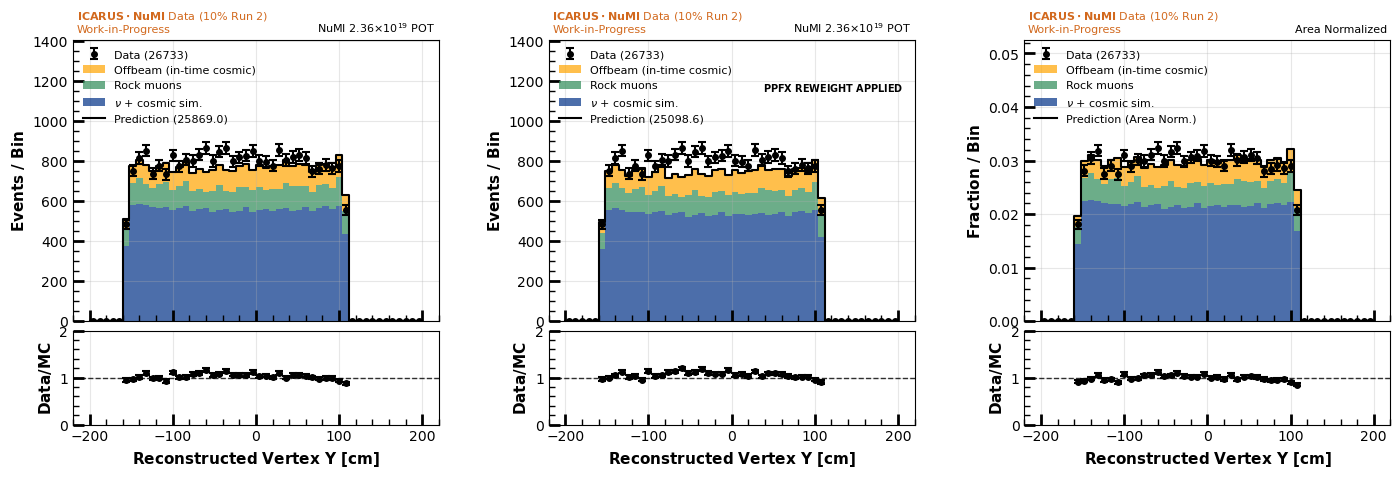

Saved: preselection_vertex_y


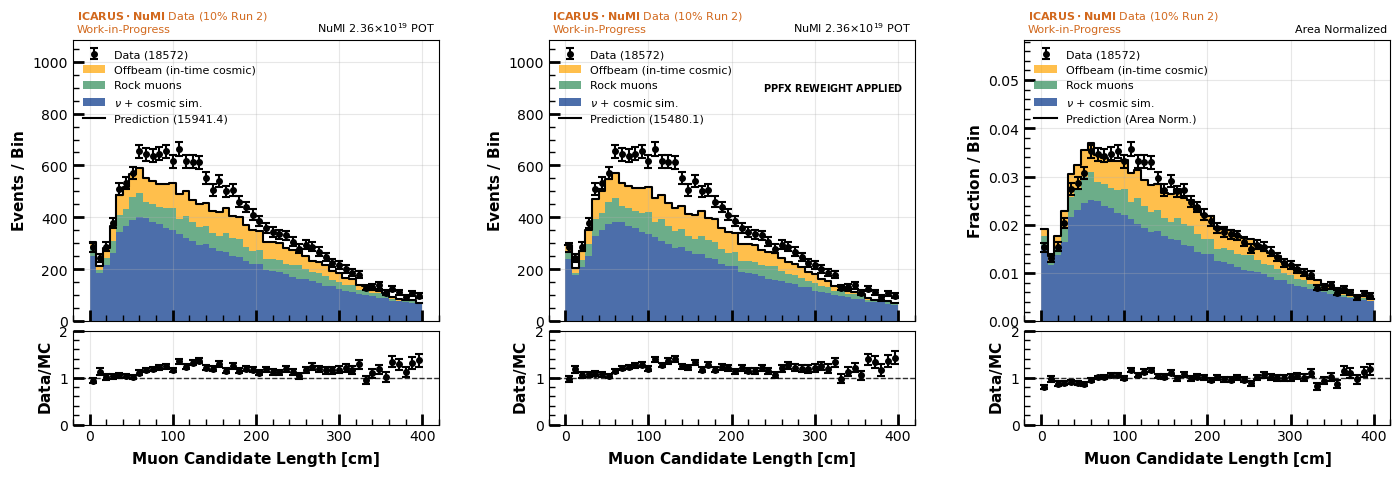

Saved: preselection_track_length
Done.


In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

def add_ppfx_label(ax):
    ax.text(0.97, 0.85, r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$',
            transform=ax.transAxes,
            fontsize=7, color='black',
            horizontalalignment='right',
            verticalalignment='top',
            fontfamily="sans-serif")

# ============================================================
# Load PPFX weights
# ============================================================
flux = uproot.open(FLUX_FILE)

ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']

numu_values    = ppfx_numu.values()
numu_edges     = ppfx_numu.axes[0].edges()
numubar_values = ppfx_numubar.values()
numubar_edges  = ppfx_numubar.axes[0].edges()

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

onbeam_lt   = f["events/onbeam/Livetime"].values().sum()
offbeam_lt  = f["events/offbeam/Livetime"].values().sum()
rock_pot    = f["events/rock/POT"].values().sum()

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}  (rock POT = {rock_pot:.4e})")

print("Loading MC preselection tree...")
mc      = f["events/nominal/preselection"].arrays(library="pd")
rock    = f["events/rock/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

# ============================================================
# Compute PPFX weights (nominal and rock)
# ============================================================
def compute_ppfx(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))

    mask_numu = (pdg == 14) & np.isfinite(nu_e)
    if mask_numu.sum() > 0:
        idx = np.searchsorted(numu_edges, nu_e[mask_numu]) - 1
        idx = np.clip(idx, 0, len(numu_values) - 1)
        w[mask_numu] = numu_values[idx]

    mask_numubar = (pdg == -14) & np.isfinite(nu_e)
    if mask_numubar.sum() > 0:
        idx = np.searchsorted(numubar_edges, nu_e[mask_numubar]) - 1
        idx = np.clip(idx, 0, len(numubar_values) - 1)
        w[mask_numubar] = numubar_values[idx]

    w[~np.isfinite(nu_e) | ~np.isfinite(pdg)] = 1.0
    return w, mask_numu, mask_numubar

print("Computing PPFX weights (nominal)...")
ppfx_mc, mask_numu_mc, mask_numubar_mc = compute_ppfx(mc)
mc["ppfx_weight"] = ppfx_mc

print("Computing PPFX weights (rock)...")
ppfx_rock, mask_numu_rock, mask_numubar_rock = compute_ppfx(rock)
rock["ppfx_weight"] = ppfx_rock

print(f"Nominal: νμ {mask_numu_mc.sum()}, ν̄μ {mask_numubar_mc.sum()}, mean weight {ppfx_mc.mean():.4f}")
print(f"Rock:    νμ {mask_numu_rock.sum()}, ν̄μ {mask_numubar_rock.sum()}, mean weight {ppfx_rock.mean():.4f}")

# ============================================================
# Plot: No PPFX (left) | PPFX (middle) | Area normalized (right)
# ============================================================
def make_howard_plot(variable, xlabel, bins, range_, output_name, require_flash_match=False):

    fig = plt.figure(figsize=(17, 5))
    gs  = gridspec.GridSpec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    ax0  = fig.add_subplot(gs[0, 0])
    ax0r = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax1  = fig.add_subplot(gs[0, 1])
    ax1r = fig.add_subplot(gs[1, 1], sharex=ax1)
    ax2  = fig.add_subplot(gs[0, 2])
    ax2r = fig.add_subplot(gs[1, 2], sharex=ax2)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    # Optional flash-match requirement (applied consistently to all samples)
    if require_flash_match:
        mc_mask      = (mc["reco_flash_time"]      > 0.0) & (mc["reco_flash_time"]      < 9.6)
        rock_mask    = (rock["reco_flash_time"]    > 0.0) & (rock["reco_flash_time"]    < 9.6)
        offbeam_mask = (offbeam["reco_flash_time"] > 0.0) & (offbeam["reco_flash_time"] < 9.6)
        onbeam_mask  = (onbeam["reco_flash_time"]  > 0.0) & (onbeam["reco_flash_time"]  < 9.6)
    else:
        mc_mask      = np.ones(len(mc),      dtype=bool)
        rock_mask    = np.ones(len(rock),    dtype=bool)
        offbeam_mask = np.ones(len(offbeam), dtype=bool)
        onbeam_mask  = np.ones(len(onbeam),  dtype=bool)

    # Histograms
    w_mc_noppfx   = np.ones(mc_mask.sum())   * mc_scale
    w_mc_ppfx     = mc.loc[mc_mask, "ppfx_weight"].values * mc_scale
    w_rock_noppfx = np.ones(rock_mask.sum()) * rock_scale
    w_rock_ppfx   = rock.loc[rock_mask, "ppfx_weight"].values * rock_scale

    mc_noppfx,   _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_noppfx)
    mc_ppfx,     _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_ppfx)
    rock_noppfx, _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_noppfx)
    rock_ppfx,   _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_ppfx)
    offbeam_h,   _ = np.histogram(offbeam.loc[offbeam_mask, variable].values, bins=bins, range=range_)
    onbeam_h,    _ = np.histogram(onbeam.loc[onbeam_mask, variable].values,   bins=bins, range=range_)
    onbeam_err     = np.sqrt(onbeam_h)

    offbeam_pot  = offbeam_h * offbeam_scale
    pred_noppfx  = mc_noppfx + rock_noppfx + offbeam_pot
    pred_ppfx    = mc_ppfx   + rock_ppfx   + offbeam_pot

    # Area normalized (no PPFX needed - shape comparison only)
    total_data        = onbeam_h.sum()
    norm_factor       = total_data / pred_noppfx.sum() if pred_noppfx.sum() > 0 else 1.0
    mc_area_f          = mc_noppfx   * norm_factor / total_data
    rock_area_f         = rock_noppfx * norm_factor / total_data
    offbeam_area_f      = offbeam_pot * norm_factor / total_data
    pred_area_f          = pred_noppfx * norm_factor / total_data
    onbeam_area_f   = onbeam_h   / total_data
    onbeam_err_f    = onbeam_err / total_data

    def draw_panel(ax, mc_vals, rock_vals, offbeam_vals, pred_vals,
                   data_vals, data_err, ylabel, pot_str, ppfx=False):
        bottoms = np.zeros(len(bins) - 1)
        ax.bar(bin_centers, mc_vals, width=bin_width, bottom=bottoms,
               color="#003087", alpha=0.7, label=r"$\nu$ + cosmic sim.")
        bottoms = bottoms + mc_vals
        ax.bar(bin_centers, rock_vals, width=bin_width, bottom=bottoms,
               color="seagreen", alpha=0.7, label="Rock muons")
        bottoms = bottoms + rock_vals
        ax.bar(bin_centers, offbeam_vals, width=bin_width, bottom=bottoms,
               color="orange",  alpha=0.7, label="Offbeam (in-time cosmic)")
        ax.step(np.append(bins[:-1], bins[-1]),
                np.append(pred_vals, pred_vals[-1]),
                where='post', color='black', linewidth=1.5,
                label=f"Prediction ({pred_vals.sum():.1f})" if pred_vals.sum() > 1.5 else "Prediction (Area Norm.)")
        ax.errorbar(bin_centers, data_vals, yerr=data_err,
                    fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black",
                    color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                    label=f"Data ({int(total_data)})", zorder=5)
        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ymax = ax.get_ylim()[1]
        ax.set_ylim(0, ymax * 1.5)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1], fontsize=8, loc='upper left',
                  framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str)
        if ppfx:
            add_ppfx_label(ax)

    def draw_ratio(ax, pred_vals, data_vals, data_err, xlabel):
        with np.errstate(invalid="ignore", divide="ignore"):
            ratio     = np.where(pred_vals > 0, data_vals / pred_vals, np.nan)
            ratio_err = np.where(pred_vals > 0, data_err  / pred_vals, np.nan)
        ax.errorbar(bin_centers, ratio, yerr=ratio_err,
                    fmt='o', markersize=4,
                    markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    # Left: no PPFX
    draw_panel(ax0, mc_noppfx, rock_noppfx, offbeam_pot, pred_noppfx,
               onbeam_h, onbeam_err,
               ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT",
               ppfx=False)
    draw_ratio(ax0r, pred_noppfx, onbeam_h, onbeam_err, xlabel)

    # Middle: with PPFX
    draw_panel(ax1, mc_ppfx, rock_ppfx, offbeam_pot, pred_ppfx,
               onbeam_h, onbeam_err,
               ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT",
               ppfx=True)
    draw_ratio(ax1r, pred_ppfx, onbeam_h, onbeam_err, xlabel)

    # Right: area normalized (no PPFX)
    draw_panel(ax2, mc_area_f, rock_area_f, offbeam_area_f, pred_area_f,
               onbeam_area_f, onbeam_err_f,
               ylabel=r"$\mathbf{Fraction\ /\ Bin}$",
               pot_str="Area Normalized",
               ppfx=False)
    draw_ratio(ax2r, pred_area_f, onbeam_area_f, onbeam_err_f, xlabel)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}")

# ============================================================
# Generate plots
# ============================================================
make_howard_plot("reco_flash_time",     "Flash Time [us]",              np.linspace(-5, 15, 51),      (-5, 15),      output_name="preselection_flash_time")
make_howard_plot("reco_flash_total_pe", "Flash Total PE",               np.linspace(0, 5000, 51),     (0, 5000),     output_name="preselection_flash_total_pe")
make_howard_plot("reco_vertex_x",       "Reconstructed Vertex X [cm]",  np.linspace(-400, 400, 51),   (-400, 400),   output_name="preselection_vertex_x", require_flash_match=True)
make_howard_plot("reco_vertex_z",       "Reconstructed Vertex Z [cm]",  np.linspace(-1000, 1000, 51), (-1000, 1000), output_name="preselection_vertex_z", require_flash_match=True)
make_howard_plot("reco_vertex_y",       "Reconstructed Vertex Y [cm]",  np.linspace(-200, 200, 51),   (-200, 200),   output_name="preselection_vertex_y", require_flash_match=True)
make_howard_plot("reco_leading_muon_length", "Muon Candidate Length [cm]", np.linspace(0, 400, 51),    (0, 400),      output_name="preselection_track_length", require_flash_match=True)

print("Done.")

Rock preselection true_category breakdown:
  Category                Label      Count   Fraction
-------------------------------------------------------
         7             Other CC        366      0.01%
         8             Other CC        902      0.03%
         9                 ν NC        347      0.01%
        10               Cosmic    2714329     99.94%
     TOTAL                         2715944


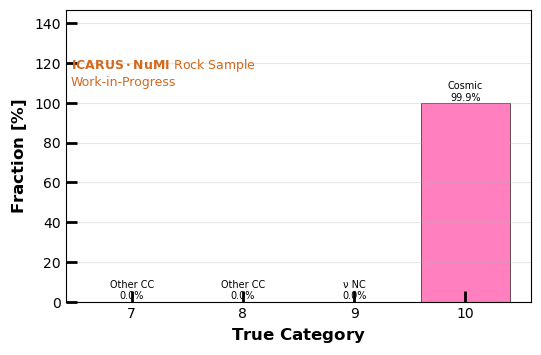

Saved: rock_category_breakdown


In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

CATEGORY_LABELS = {
    0:  "Signal (QE)",
    1:  "Signal (QE)",
    2:  "OOFV",
    3:  "Signal (RES)",
    4:  "Signal (other)",
    5:  "OOFV",
    6:  "Other CC",
    7:  "Other CC",
    8:  "Other CC",
    9:  "ν NC",
    10: "Cosmic",
}

CATEGORY_COLORS = {
    0:  "#003087",
    1:  "#003087",
    2:  "#2E8B57",
    3:  "#003087",
    4:  "#003087",
    5:  "#2E8B57",
    6:  "#FFD100",
    7:  "#FFD100",
    8:  "#FFD100",
    9:  "#CC0000",
    10: "#FF69B4",
}

f = uproot.open(DATA_FILE)
rock = f["events/rock/preselection"].arrays(library="pd")

cats = rock["true_category"].value_counts().sort_index()
total = cats.sum()

print("Rock preselection true_category breakdown:")
print(f"{'Category':>10} {'Label':>20} {'Count':>10} {'Fraction':>10}")
print("-" * 55)
for cat, count in cats.items():
    label = CATEGORY_LABELS.get(int(cat), f"Unknown ({cat})")
    print(f"{cat:>10.0f} {label:>20} {count:>10} {count/total:>10.2%}")
print(f"{'TOTAL':>10} {'':>20} {total:>10}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
fig.subplots_adjust(bottom=0.15)

bars = ax.bar(
    [str(int(c)) for c in cats.index],
    cats.values / total * 100,
    color=[CATEGORY_COLORS.get(int(c), "grey") for c in cats.index],
    alpha=0.85, edgecolor='black', linewidth=0.5
)

for bar, (cat, count) in zip(bars, cats.items()):
    label = CATEGORY_LABELS.get(int(cat), f"?")
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{label}\n{count/total:.1%}",
            ha='center', va='bottom', fontsize=7, fontfamily='sans-serif')

ax.set_xlabel(r"$\mathbf{True\ Category}$", fontsize=12)
ax.set_ylabel(r"$\mathbf{Fraction\ [\%]}$", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
ax.grid(True, alpha=0.3, axis='y')

yrange = ax.get_ylim()
xrange = ax.get_xlim()
usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
ax.text(usex, usey,
        r'$\bf{ICARUS \cdot NuMI}$' + ' Rock Sample\nWork-in-Progress',
        fontsize=9, color="chocolate",
        verticalalignment="bottom", fontfamily="sans-serif")

ax.set_ylim(0, ax.get_ylim()[1] * 1.4)

os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "pdf/rock_category_breakdown.pdf"),   bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, "jpeg/rock_category_breakdown.jpeg"), bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
print("Saved: rock_category_breakdown")

In [2]:
"""
Overlap between the 1muNp0pi (this analysis) and Howard's CC0piNp (CC mesonless,
SBN DocDB 47077 ref [9]) signal definitions.

Computed on the truth-level signal tree of the nominal MC:
    events/nominal/signal  in  1muNp0pi_Nge1_uncontained.root

Logic
-----
Both analyses share the same muon threshold (p_mu > 226 MeV/c, equivalently
KE_mu > 143.425 MeV) and both include numu + numubar CC, so within our signal
tree the only discriminating requirements from Howard's definition are:

  (1) Leading proton momentum in [0.4, 1.0] GeV/c
      (ours: any proton with KE > 50 MeV, i.e. p > 0.310 GeV/c, no upper bound)

  (2) No primary charged pion at ANY energy
      (ours: none above 25 MeV KE, so only primary pions BELOW 25 MeV can
      distinguish the two definitions inside our signal)

Caveat on (2): the true_leading_pion_* branches are filled by the leading_pion
selector (selectors.h), which loops over ALL pions in the interaction with no
primary requirement. The signal definition itself uses pion_multiplicity
(variables.h), which counts only PRIMARY pions with KE >= 25 MeV. Therefore:
  - entries with true_leading_pion_ke > 25 MeV are necessarily NON-primary
    (Geant4 secondaries) -> irrelevant to both signal definitions;
  - entries with true_leading_pion_ke < 25 MeV are an UPPER BOUND on events
    with a soft primary pion (some are soft secondaries).

Not evaluable from these branches (neglected): Howard's photon (>10 MeV) and
other-hadron checks, and fiducial-volume differences.

Counts are raw MC events (no flux/PPFX/CV weights).
"""

import numpy as np
import uproot

FNAME = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
TREE = "events/nominal/signal"

P_LOW, P_HIGH = 0.4, 1.0   # Howard leading-proton window [GeV/c]
PI_THR = 25.0              # our primary charged-pion KE threshold [MeV]

tree = uproot.open(FNAME)[TREE]
arr = tree.arrays(
    ["true_leading_proton_momentum",   # GeV/c
     "true_leading_pion_ke"],          # MeV; NaN if no pion of any kind
    library="np",
)

p_lp = arr["true_leading_proton_momentum"]
pi_ke = arr["true_leading_pion_ke"]
n = len(p_lp)

# Sanity check: our proton threshold KE > 50 MeV corresponds to
# p = sqrt((50 + 938.272)^2 - 938.272^2) = 310 MeV/c, so the minimum
# leading-proton momentum in the tree should be ~0.310 GeV/c.
print(f"entries in signal tree           : {n}")
print(f"min leading proton momentum      : {np.min(p_lp):.4f} GeV/c (expect ~0.310)\n")

# --- (1) Howard's leading-proton window --------------------------------------
in_window = (p_lp > P_LOW) & (p_lp < P_HIGH)
below = p_lp <= P_LOW
above = p_lp >= P_HIGH

# --- (2) pion bookkeeping -----------------------------------------------------
has_pion_branch = ~np.isnan(pi_ke)              # any pion, primary or not
pion_above_thr = has_pion_branch & (pi_ke > PI_THR)   # necessarily non-primary
pion_below_thr = has_pion_branch & (pi_ke <= PI_THR)  # upper bound on soft primaries

print(f"pion branch filled (any pion)    : {has_pion_branch.sum()}")
print(f"  KE > {PI_THR:.0f} MeV (non-primary)     : {pion_above_thr.sum()}")
print(f"  KE <= {PI_THR:.0f} MeV (soft, upper bnd): {pion_below_thr.sum()} "
      f"({100*pion_below_thr.mean():.2f}% of signal)\n")

# --- Overlap ------------------------------------------------------------------
# Central value: proton window only (soft-primary-pion correction is < 0.2%,
# below the precision of this estimate).
overlap = in_window
# Lower bound: additionally drop every event with any pion below threshold.
overlap_lb = in_window & ~pion_below_thr

def line(label, mask):
    print(f"{label:45s}: {mask.sum():6d}  ({100*mask.mean():.1f}%)")

line(f"leading proton in ({P_LOW}, {P_HIGH}) GeV/c", in_window)
line(f"leading proton <= {P_LOW} GeV/c", below)
line(f"leading proton >= {P_HIGH} GeV/c", above)
print()
line("OVERLAP (window only, central value)", overlap)
line("overlap minus soft-pion upper bound", overlap_lb)

entries in signal tree           : 113501
min leading proton momentum      : 0.3104 GeV/c (expect ~0.310)

pion branch filled (any pion)    : 1888
  KE > 25 MeV (non-primary)     : 1704
  KE <= 25 MeV (soft, upper bnd): 184 (0.16% of signal)

leading proton in (0.4, 1.0) GeV/c           :  80617  (71.0%)
leading proton <= 0.4 GeV/c                  :  17534  (15.4%)
leading proton >= 1.0 GeV/c                  :  15350  (13.5%)

OVERLAP (window only, central value)         :  80617  (71.0%)
overlap minus soft-pion upper bound          :  80566  (71.0%)
